# Projet ML — Crédit Bancaire (German Credit Risk)

## Contexte métier
Une banque souhaite automatiser l'évaluation du risque crédit de ses clients.  
L'enjeu est double : **ne pas refuser un bon client** et surtout **ne pas accorder un crédit à quelqu'un qui ne remboursera pas**.

## Dataset
- Source : German Credit Risk — Kaggle
- 1 000 clients, 10 features (âge, montant, durée, type de compte...)
- Variable cible : `Risk` → `good` (bon payeur) ou `bad` (mauvais payeur)

## Approche
- Algorithme : **KNN (K-Nearest Neighbors)** — Classification supervisée
- Séparation : **75% entraînement / 25% test** avec `train_test_split`
- Évaluation : accuracy, precision, recall, f1-score

## Plan
1. Importer les librairies
2. Charger et explorer les données
3. Visualiser
4. Préparer X et y
5. train_test_split
6. Entraîner le modèle KNN
7. Évaluer les résultats
8. Trouver le meilleur k automatiquement

## Étape 1 — Librairies

- `pandas` : manipulation des données (lecture CSV, filtrage, encodage)
- `matplotlib` : visualisation des graphiques
- `KNeighborsClassifier` : l'algorithme KNN de scikit-learn
- `train_test_split` : séparation entraînement / test

In [1]:
# imports
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("Data/GermanData.csv", index_col=0)
df.head()   

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## Étape 2 — Explorer les données

On commence par comprendre ce qu'on a avant de modéliser.  
Règle fondamentale : **on ne modélise jamais des données qu'on n'a pas explorées.**

In [4]:
# chargement et exploration
df = pd.read_csv("Data/GermanData.csv", index_col=0)
df.head()   

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.shape

(1000, 10)

In [6]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


## Ce qu'on voit dans les données

- L'âge moyen des clients est **35 ans** — ce sont surtout des jeunes qui demandent des crédits
- Le montant moyen emprunté est **3 271 €** — des achats du quotidien (voiture, télé, meubles)
- La durée moyenne est **21 mois** — environ 2 ans pour rembourser
- Certains clients empruntent jusqu'à **18 424 €** — ce sont des cas rares mais ils existent

Deux colonnes ont des cases vides (type de compte épargne et type de compte courant).
On ne les utilisera pas pour l'instant — on garde uniquement les colonnes complètes.

## Étape 3 — Visualiser

Deux visualisations clés :
1. **Répartition good/bad** → vérifie si les classes sont équilibrées
2. **Scatter plot Age vs Montant** → cherche une séparation visuelle entre bons et mauvais payeurs

<Axes: xlabel='Risk'>

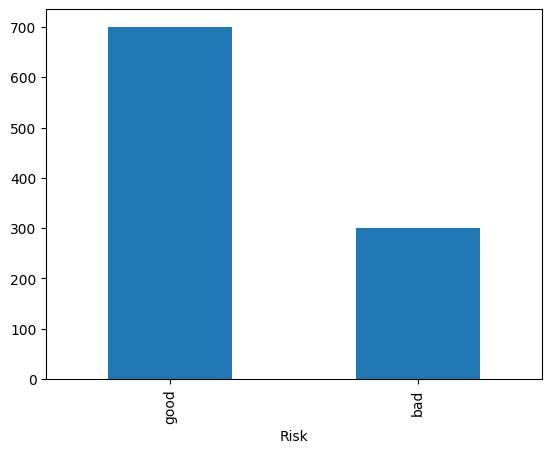

In [7]:
# visualisation
df['Risk'].value_counts().plot(kind='bar')

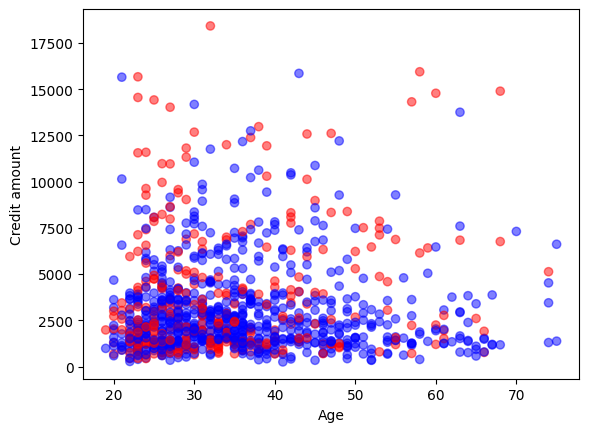

In [8]:
colors = df['Risk'].map({'good': 'blue', 'bad': 'red'})
plt.scatter(df['Age'], df['Credit amount'], c=colors, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Credit amount')
plt.show()

## Ce qu'on voit dans les graphiques

**Graphique 1 — Combien de bons et mauvais payeurs ?**
- Il y a **700 bons payeurs** et **300 mauvais payeurs**
- Ce n'est pas équilibré — il y a 2 fois plus de bons payeurs que de mauvais
- Conséquence : le modèle va naturellement mieux reconnaître les bons payeurs

**Graphique 2 — Age vs Montant du crédit**
- Les points rouges (mauvais payeurs) et bleus (bons payeurs) sont mélangés partout
- On ne peut pas tracer une ligne droite pour les séparer
- C'est pour ça qu'on a besoin d'un algorithme intelligent comme KNN

## Visualisation 3D — Age, Montant, Durée par Risque

On place chaque client dans un espace 3D :
- **Axe X** = Age
- **Axe Y** = Montant du crédit
- **Axe Z** = Durée du crédit
- **Couleur** = Risque (bleu = bon payeur, rouge = mauvais payeur)

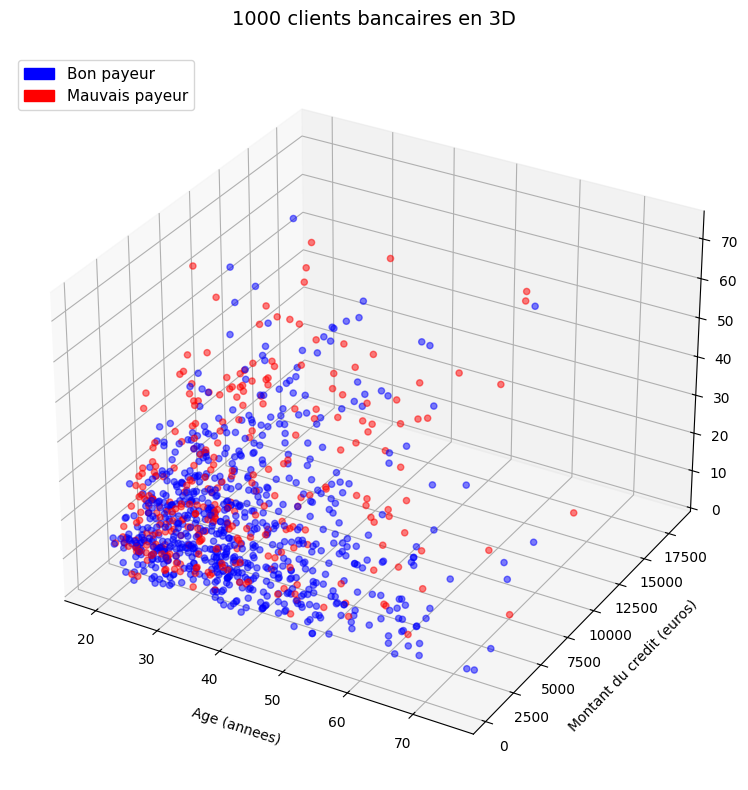

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = df['Risk'].map({'good': 'blue', 'bad': 'red'})

ax.scatter(
    df['Age'],
    df['Credit amount'],
    df['Duration'],
    c=colors,
    alpha=0.5,
    s=20
)

ax.set_xlabel('Age (annees)', labelpad=10)
ax.set_ylabel('Montant du credit (euros)', labelpad=10)
ax.set_zlabel('Duree du credit (mois)', labelpad=10)
ax.set_title('1000 clients bancaires en 3D', fontsize=14, pad=20)

# Legende
bleu = mpatches.Patch(color='blue', label='Bon payeur')
rouge = mpatches.Patch(color='red', label='Mauvais payeur')
ax.legend(handles=[bleu, rouge], loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

## Pourquoi on remplace "good"/"bad" par 1 et 0 ?

### Le problème
La heatmap calcule des **corrélations** entre les colonnes.
Une corrélation, c'est une formule mathématique — elle ne comprend que des **nombres**.
Si on lui donne les mots "good" et "bad", elle plante. Il faut donc les traduire en chiffres.

On choisit :
- **good → 1** (bon payeur)
- **bad → 0** (mauvais payeur)

---

### Est-ce que la somme va donner zéro ?

Non. Exemple avec nos 1000 clients :
- 700 bons payeurs × 1 = **700**
- 300 mauvais payeurs × 0 = **0**
- Total = **700**

Ce n'est pas zéro. La formule utilise cette somme pour comparer les colonnes entre elles.

---

### Comment la corrélation fonctionne concrètement

La formule regarde si **deux colonnes bougent ensemble**.

**Exemple — Durée et Risque :**

Imagine 4 clients :

| Client | Durée (mois) | Risque (1=bon, 0=mauvais) |
|--------|-------------|--------------------------|
| A | 6 mois | 1 (bon payeur) |
| B | 12 mois | 1 (bon payeur) |
| C | 36 mois | 0 (mauvais payeur) |
| D | 48 mois | 0 (mauvais payeur) |

On voit que quand la durée **augmente**, le risque **diminue** (passe de 1 à 0).
→ Durée et Risque bougent dans des **sens opposés**
→ Corrélation **négative** (-0.21 dans notre heatmap)

**Traduction simple :** plus un client emprunte longtemps, plus il a de chances d'être un mauvais payeur.

---

### Les 3 valeurs importantes de notre heatmap

| Feature | Corrélation avec Risk | Ce que ça veut dire |
|---------|----------------------|---------------------|
| Durée | **-0.21** | Crédit long = plus risqué |
| Montant | **-0.15** | Gros montant = un peu plus risqué |
| Age | **+0.09** | Client âgé = légèrement meilleur payeur |

→ On garde ces 3 colonnes comme features X pour entraîner le modèle.

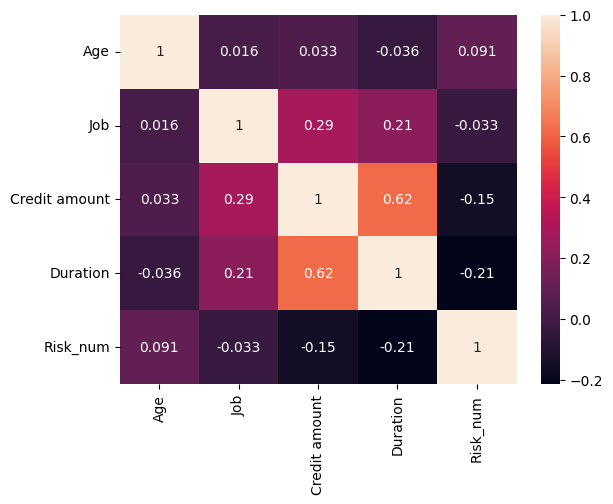

In [10]:
# Encodage temporaire pour voir les corrélations
df['Risk_num'] = df['Risk'].map({'good': 1, 'bad': 0})

# Heatmap des corrélations avec Risk
import seaborn as sns
sns.heatmap(df[['Age', 'Job', 'Credit amount', 'Duration', 'Risk_num']].corr(), annot=True)
plt.show()

## Quelles informations sont liées au risque ?

On a regardé si chaque information sur le client est liée au fait qu'il rembourse ou pas.

| Information | Lien avec le risque | Explication simple |
|-------------|--------------------|--------------------|
| Durée du crédit | **Oui (fort)** | Plus on emprunte longtemps, plus le risque augmente |
| Montant emprunté | **Un peu** | Plus on emprunte, plus le risque augmente légèrement |
| Age | **Très peu** | Les clients plus âgés remboursent un tout petit peu mieux |
| Type de job | **Presque rien** | Le job n'aide pas à prédire le risque |

On garde **Age, Montant et Durée** — ce sont les 3 colonnes les plus utiles sans cases vides.

## Étape 4 — Préparer X et y

**X** = les features (ce que le modèle observe) : `Age`, `Credit amount`, `Duration`  
**y** = la cible (ce que le modèle doit prédire) : `Risk` encodé en 0/1

Pourquoi encoder `Risk` en nombre ? KNN calcule des **distances mathématiques** entre les points.  
Il ne peut pas calculer la distance entre "good" et "bad" — mais il peut entre 1 et 0.

In [11]:
# encodage et préparation X, y
# On garde uniquement Age, Credit amount, Duration
X = df[['Age', 'Credit amount', 'Duration']]

# On encode Risk : good=1, bad=0
#map() c'est une méthode pandas qui remplace des valeurs selon un dictionnaire.

#Tu lui donnes un dictionnaire : {'good': 1, 'bad': 0}

#Il lit chaque valeur de la colonne Risk et remplace :

#"good" → 1
#"bad" → 0
#C'est comme faire un chercher/remplacer dans Excel mais en Python.

#Écris les 2 lignes et affiche X.shape et y.shape.
y = df['Risk'].map({'good': 1, 'bad': 0})
y = df['Risk'].map({'good':1,'bad':0})

## Étape 5 — Séparation entraînement / test (train_test_split)

**Pourquoi séparer les données ?**  
Si on évalue le modèle sur les mêmes données qu'il a vues pendant l'entraînement, il "triche" — il connaît déjà les réponses.  
C'est comme donner les corrections à un élève avant l'examen.

**75% entraînement** → le modèle apprend sur 750 clients  
**25% test** → on évalue sur 250 clients que le modèle n'a jamais vus  

`random_state=42` : fixe le hasard pour que la séparation soit toujours la même à chaque exécution.

In [12]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [13]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (750, 3)
X_test  : (250, 3)


## Étape 6 — Algorithme KNN (K-Nearest Neighbors)

**Principe :** Pour prédire si un nouveau client est bon ou mauvais payeur, KNN regarde ses `k` voisins les plus proches dans les données d'entraînement et vote à la majorité.

**Exemple avec k=5 :**  
→ Le modèle trouve les 5 clients les plus similaires (en âge, montant, durée)  
→ Si 4 sur 5 sont bons payeurs → prédit "good"  
→ Si 3 sur 5 sont mauvais payeurs → prédit "bad"

**Deux versions testées :**
1. Sans normalisation → features dans des échelles différentes (âge en années, montant en euros)
2. Avec normalisation (`StandardScaler`) → toutes les features ramenées à la même échelle → meilleur résultat

In [14]:
from sklearn.metrics import classification_report


In [15]:
# modèle KNN
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train, y_train)
y_pred = KNN.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.21      0.26        72
           1       0.73      0.85      0.78       178

    accuracy                           0.66       250
   macro avg       0.54      0.53      0.52       250
weighted avg       0.62      0.66      0.63       250



In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
# Normalisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train_scaled, y_train)
y_pred = KNN.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.41      0.29      0.34        72
           1       0.74      0.83      0.79       178

    accuracy                           0.68       250
   macro avg       0.58      0.56      0.56       250
weighted avg       0.65      0.68      0.66       250



## Lire le rapport du modèle — ligne par ligne

Le modèle a testé sur **250 clients** qu'il n'avait jamais vus.
Voici comment lire chaque chiffre :

---

### Les 4 colonnes : Precision, Recall, F1-score, Support

**Support** — combien de vrais clients de cette catégorie dans le test :
- 72 vrais mauvais payeurs (classe 0)
- 178 vrais bons payeurs (classe 1)

---

**Precision** — sur tous les clients que le modèle a dit "mauvais payeur", combien l'étaient vraiment ?
- Classe 0 : **0.41** → sur 10 clients que le modèle accuse d'être mauvais payeurs, seulement 4 le sont vraiment. Il fait beaucoup de fausses accusations.
- Classe 1 : **0.74** → sur 10 clients que le modèle dit bons payeurs, 7 le sont vraiment.

---

**Recall** — sur tous les vrais mauvais payeurs, combien le modèle en a détecté ?
- Classe 0 : **0.29** → sur 72 vrais mauvais payeurs, il n'en a trouvé que 21. Il en rate 51.
- Classe 1 : **0.83** → sur 178 vrais bons payeurs, il en a bien reconnu 148.

---

**F1-score** — la moyenne entre Precision et Recall. C'est le score global d'une classe.
- Classe 0 : **0.34** → faible — le modèle est mauvais sur les mauvais payeurs
- Classe 1 : **0.79** → correct — le modèle est bon sur les bons payeurs

---

**Accuracy (0.68)** — sur 250 clients, le modèle a eu raison 68% du temps.
Attention : ce chiffre est trompeur ici. Il est élevé parce qu'il y a beaucoup plus de bons payeurs (178) que de mauvais (72). Le modèle "triche" en disant presque toujours "bon payeur".

---

**Macro avg** — moyenne simple entre classe 0 et classe 1 (50% / 50%).
- F1 macro : 0.56 → résultat moyen si on traite les deux classes de manière égale

**Weighted avg** — moyenne pondérée selon le nombre de clients dans chaque classe.
- F1 weighted : 0.66 → résultat moyen en tenant compte qu'il y a 2,5 fois plus de bons payeurs

---

## Pourquoi le score est passé de 66% à 68% avec la normalisation ?

**Modèle 1 — sans normalisation :**
- Age : entre 19 et 75 ans → écart de 56
- Montant : entre 250 et 18 424 euros → écart de 18 174
- Durée : entre 4 et 72 mois → écart de 68

KNN calcule des distances entre clients. Sans normalisation, le **montant en euros domine tout** — un écart de 1000€ écrase un écart de 10 ans d'âge. Le modèle ne "voit" presque que le montant.

**Modèle 2 — avec normalisation (StandardScaler) :**
- On remet toutes les colonnes à la même échelle (moyenne 0, écart-type 1)
- Age, Montant et Durée ont maintenant le même poids dans le calcul de distance
- Le modèle "voit" les 3 variables de manière équilibrée
- Résultat : accuracy 68% au lieu de 66%, recall mauvais payeurs 29% au lieu de 21%

**Gain de 2%** — petit mais réel. La normalisation est toujours recommandée avec KNN.

## Est-ce que le modèle est bon ?

### Les résultats en clair

Le modèle a regardé **250 clients** qu'il n'avait jamais vus.

**Pour les bons payeurs :**
- Il en a bien reconnu **83 sur 100** → correct

**Pour les mauvais payeurs :**
- Il n'en a reconnu que **29 sur 100** → très faible

**Score global : 68%** des prédictions sont correctes.

### Ce que ça veut dire pour une banque

Sur 72 vrais mauvais payeurs dans notre test :
- Le modèle en a détecté **21** correctement
- Les **51 autres** ont été classés comme bons payeurs — la banque leur aurait accordé un crédit à tort

C'est le vrai problème de ce modèle.

### Pourquoi c'est faible ?
- Il y a beaucoup plus de bons payeurs que de mauvais dans les données → le modèle a appris à dire "bon payeur" par défaut
- Les 3 informations qu'on utilise (age, montant, durée) ne suffisent pas pour bien prédire

### La normalisation aide un peu
Quand on remet toutes les données à la même échelle (âge en années, montant en euros — très différents), le modèle passe de 66% à 68%. Petit progrès, pas suffisant.

## Evaluation : entrainement vs test

On compare le score entrainement vs le score test.
Si score entrainement >> score test = overfitting.

In [19]:
print('Score entrainement :', round(KNN.score(X_train, y_train), 3))
print('Score test         :', round(KNN.score(X_test, y_test), 3))

Score entrainement : 0.304
Score test         : 0.288


C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


## Étape 8 — Trouver le meilleur k automatiquement

**Problème :** k=5 est un choix arbitraire. Comment savoir quel k donne les meilleurs résultats ?

**Solution :** Tester k=1 à k=20 avec une boucle `for`, stocker l'accuracy de chaque k, visualiser et trouver le maximum automatiquement.

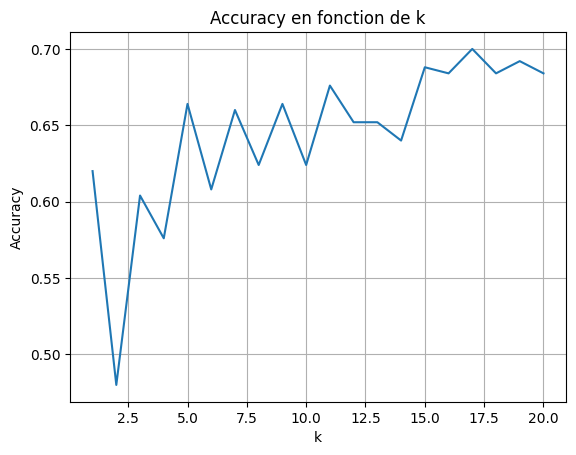

Le meilleur k est : 17
Accuracy maximale : 0.7


In [20]:
# comparaison modèles — accuracy vs k
precision = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    precision.append(knn.score(X_test, y_test))

plt.plot(range(1, 21), precision)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction de k')
plt.grid(True)
plt.show()

meilleur_index = precision.index(max(precision))
print("Le meilleur k est :", meilleur_index + 1)
print("Accuracy maximale :", round(max(precision), 3))

## Quel est le meilleur nombre de voisins ?

On a testé le modèle avec k=1, k=2, ... jusqu'à k=20 voisins.

**Ce qu'on a trouvé :**
- k=2 est le pire (~48%) — avec seulement 2 voisins, le modèle se trompe souvent
- Plus k est grand, plus le modèle devient stable
- **k=17 donne le meilleur résultat : 70%**

**Pourquoi k=17 est meilleur que k=1 ?**
Imagine que tu veux savoir si un quartier est agréable.
- Avec k=1 : tu demandes à **1 seule personne** — si elle est de mauvaise humeur, ta réponse est fausse
- Avec k=17 : tu demandes à **17 personnes** et tu prends l'avis de la majorité — beaucoup plus fiable

**Règle simple :** toujours choisir k ≥ 5 pour avoir un modèle stable.

---

## Résumé final

| Ce qu'on a testé | Score |
|-----------------|-------|
| KNN avec k=5, données brutes | 66% |
| KNN avec k=5, données normalisées | 68% |
| KNN avec k=17 (le meilleur) | **70%** |

**Ce modèle est un bon début, mais pas encore assez bon pour une vraie banque.**
Pour aller plus loin : utiliser plus d'informations sur les clients, ou tester d'autres algorithmes plus puissants.

## Pourquoi le modèle détecte seulement 21 mauvais payeurs sur 72 ?

### La vraie raison : pas assez de variables

On a donné au modèle seulement **3 informations** sur chaque client :
- L'âge
- Le montant du crédit
- La durée du crédit

Ces 3 informations ont une corrélation très faible avec le risque (maximum -0.21).
En clair : elles n'expliquent pas vraiment si quelqu'un va rembourser ou pas.

**Ce n'est pas la faute de l'algorithme KNN.**
**C'est la faute des données — on n'en a pas assez.**

---

### Ce qu'une vraie banque utilise

Une banque réelle a accès à beaucoup plus d'informations sur ses clients :

| Information | Pourquoi c'est important |
|-------------|--------------------------|
| Historique de dépenses | Un dépenseur compulsif rembourse moins bien |
| Revenus mensuels | Montre s'il peut vraiment rembourser |
| Charges fixes (loyer, autres crédits) | Montre l'argent qu'il lui reste chaque mois |
| Situation professionnelle (CDI, CDD, chômage) | Un CDI = revenus stables = moins de risque |
| Garanties (voiture, maison hypothéquée) | Si le client ne rembourse pas, la banque récupère quelque chose |
| Historique de remboursements passés | Le meilleur indicateur du comportement futur |
| Heure et fréquence des dépenses | Un client qui dépense tout le 1er du mois est plus risqué |

Avec ces variables, le recall sur les mauvais payeurs passerait de **29%** à probablement **70-80%**.

---

### La leçon fondamentale du Machine Learning

> **Un bon modèle ML dépend à 80% de la qualité des données, et à 20% de l'algorithme.**

Améliorer KNN ou changer d'algorithme n'aurait pas beaucoup changé les résultats ici.
Ce qu'il faudrait, c'est **plus de variables pertinentes** sur le comportement financier des clients.

C'est pour ça que les banques investissent massivement dans la collecte de données sur leurs clients.